In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor

e:\Softwares\anaconda3\envs\RAG\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('hyderabad_ride_comparison_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [3]:
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

# Route feature
df['route'] = df['pickup_location'] + ' -> ' + df['destination']

# Peak hour feature
df['is_peak_hour'] = df['hour_of_day'].apply(
    lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 21) else 0
)

# Demand score
demand_map = {
    'Low':1,
    'Medium':2,
    'High':3
}

df['demand_score'] = df['demand_level'].map(demand_map)

target = 'fare_price'

features = [
    'platform',
    'route',
    'distance_km',
    'estimated_duration_min',
    'vehicle_type',
    'base_fare',
    'surge_multiplier',
    'estimated_arrival_min',
    'driver_rating',
    'available_coupon',
    'coupon_discount',
    'cashback',
    'demand_level',
    'weather_condition',
    'traffic_level',
    'day_of_week',
    'hour_of_day',
    'festival_indicator',
    'month',
    'day',
    'is_weekend',
    'is_peak_hour',
    'demand_score'
]

X = df[features].copy()
y = df[target]

In [4]:
categorical_features = [
    'platform',
    'route',
    'vehicle_type',
    'demand_level',
    'weather_condition',
    'traffic_level',
    'day_of_week'
]

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [5]:
numerical_features = [
    col for col in features
    if col not in categorical_features
]

# Standardize numerical features
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Correlation-based attention weights
correlations = X[numerical_features].corrwith(y).abs()
attention_weights = correlations / correlations.sum()

print('='*50)
print('ATTENTION FEATURE WEIGHTS')
print('='*50)
print(attention_weights.sort_values(ascending=False))
print('='*50)

ATTENTION FEATURE WEIGHTS
estimated_duration_min    0.208695
distance_km               0.202858
base_fare                 0.133579
surge_multiplier          0.100674
demand_score              0.092661
estimated_arrival_min     0.074504
is_peak_hour              0.048399
festival_indicator        0.037853
coupon_discount           0.036597
hour_of_day               0.022069
is_weekend                0.021264
day                       0.012455
cashback                  0.006124
driver_rating             0.001807
month                     0.000375
available_coupon          0.000086
dtype: float64


In [6]:
for col in numerical_features:
    X[col] = X[col] * attention_weights[col]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 261.0075817	test: 255.9803621	best: 255.9803621 (0)	total: 160ms	remaining: 1m 51s
100:	learn: 44.9595056	test: 48.6739065	best: 48.6739065 (100)	total: 601ms	remaining: 3.57s
200:	learn: 27.8044340	test: 33.2134265	best: 33.2134265 (200)	total: 1.04s	remaining: 2.58s
300:	learn: 23.7243062	test: 29.9913496	best: 29.9913496 (300)	total: 1.48s	remaining: 1.97s
400:	learn: 21.6332293	test: 28.8708516	best: 28.8708516 (400)	total: 1.96s	remaining: 1.46s
500:	learn: 19.9274525	test: 28.4140443	best: 28.4140443 (500)	total: 2.39s	remaining: 948ms
600:	learn: 18.5853726	test: 28.0946655	best: 28.0946655 (600)	total: 2.89s	remaining: 476ms
699:	learn: 17.5189561	test: 27.9567309	best: 27.9567309 (699)	total: 3.58s	remaining: 0us

bestTest = 27.95673085
bestIteration = 699



CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=700, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print('='*60)
print('ATTENTION-ENHANCED EXPLAINABLE CATBOOST FRAMEWORK')
print('='*60)
print(f'MAE   : {mae:.4f}')
print(f'RMSE  : {rmse:.4f}')
print(f'MAPE  : {mape:.4f}%')
print(f'R²    : {r2:.4f}')
print('='*60)

ATTENTION-ENHANCED EXPLAINABLE CATBOOST FRAMEWORK
MAE   : 16.3648
RMSE  : 27.9567
MAPE  : 4.8366%
R²    : 0.9886


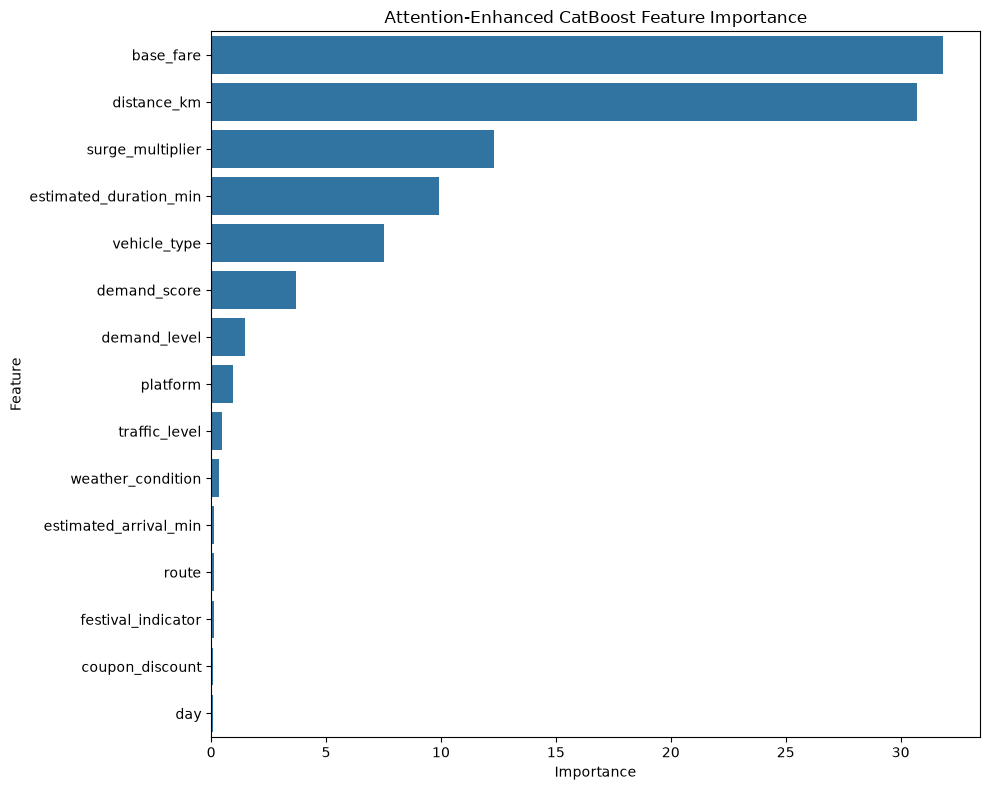

In [11]:
importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))
sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Attention-Enhanced CatBoost Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [12]:
explainer = shap.TreeExplainer(model)

sample = X_test.sample(200, random_state=42)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()
plt.savefig('shap_summary.png')
plt.close()

In [13]:
residuals = y_test - y_pred
residual_std = residuals.std()

lower_bound = y_pred - 1.96 * residual_std
upper_bound = y_pred + 1.96 * residual_std

confidence = []

for l,u in zip(lower_bound, upper_bound):
    width = u - l
    conf = max(0, 1 - width / max(y))
    confidence.append(conf)

confidence = np.mean(confidence)

print(f'Average Prediction Confidence: {confidence:.4f}')

Average Prediction Confidence: 0.9579


In [14]:
os.makedirs('ride_model', exist_ok=True)

joblib.dump(model, 'ride_model/aeecf_catboost_model.pkl')
joblib.dump(scaler, 'ride_model/scaler.pkl')
joblib.dump(label_encoders, 'ride_model/label_encoders.pkl')
joblib.dump(attention_weights, 'ride_model/attention_weights.pkl')
joblib.dump(features, 'ride_model/feature_columns.pkl')

metrics = {
    'MAE':float(mae),
    'RMSE':float(rmse),
    'MAPE':float(mape),
    'R2':float(r2),
    'Confidence':float(confidence)
}

with open('ride_model/model_metrics.json','w') as f:
    json.dump(metrics,f,indent=4)

importance_df.to_csv(
    'ride_model/feature_importance.csv',
    index=False
)

print('AEECF model saved successfully!')

AEECF model saved successfully!


In [15]:
def predict_fare(input_dataframe):
    prediction = model.predict(input_dataframe)
    return prediction

print('Model ready for Django integration!')

Model ready for Django integration!
